# Gacha EV + pity distribution

Simulates the live gacha pull logic from `app.gacha` over many trials.
Answers:
1. What's the EPIC+ rate, with and without pity?
2. How many pulls does the average player need for their first EPIC?
3. Where does the pity floor actually kick in (50 by config)?


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import os
os.environ.setdefault('HEROPROTO_ENVIRONMENT', 'dev')
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from app.gacha import roll, RATES
from app.config import settings
PITY_THRESHOLD = settings.gacha_pity_threshold

In [2]:
# Simulate 100,000 pulls from a fresh pity counter.
rng = random.Random(1312)
pulls = []
pity = 0
for _ in range(100_000):
    res = roll(pity, rng)
    pulls.append({'rarity': str(res.rarity), 'pity_before': pity, 'triggered': res.pity_triggered})
    pity = res.new_pity
df = pd.DataFrame(pulls)
df['rarity'].value_counts(normalize=True).sort_index()

rarity
COMMON       0.44588
EPIC         0.05081
LEGENDARY    0.00528
RARE         0.19981
UNCOMMON     0.29822
Name: proportion, dtype: float64

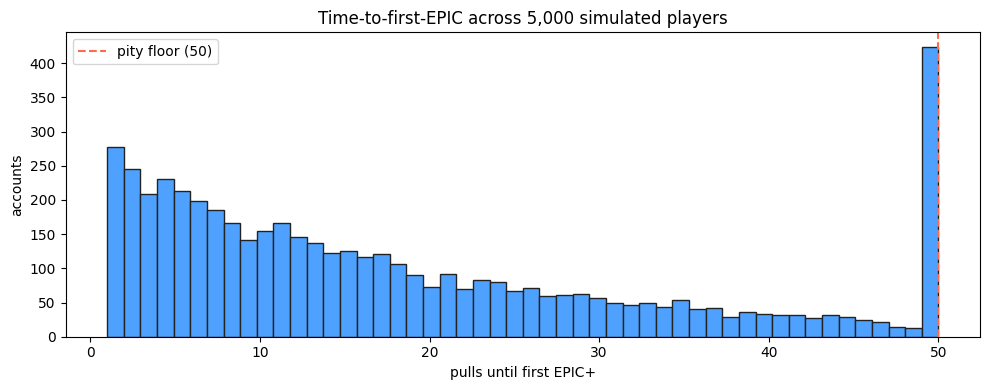

median: 14 pulls · 90th pct: 45 · max: 50


In [3]:
# Distribution of pulls-to-first-EPIC across 5,000 fresh accounts.
first_epic = []
for _ in range(5000):
    pity = 0
    for n in range(1, 200):
        res = roll(pity, rng)
        pity = res.new_pity
        if str(res.rarity) in ('EPIC', 'LEGENDARY'):
            first_epic.append(n)
            break
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(first_epic, bins=50, color='#4ea1ff', edgecolor='#222')
ax.axvline(PITY_THRESHOLD, color='#ff6b4a', linestyle='--', label=f'pity floor ({PITY_THRESHOLD})')
ax.set_xlabel('pulls until first EPIC+')
ax.set_ylabel('accounts')
ax.set_title('Time-to-first-EPIC across 5,000 simulated players')
ax.legend()
fig.tight_layout()
fig.savefig('output/gacha_first_epic.png', dpi=120, facecolor='white')
plt.show()
print(f'median: {int(np.median(first_epic))} pulls · 90th pct: {int(np.percentile(first_epic, 90))} · max: {max(first_epic)}')

In [4]:
# How often does pity actually fire? (vs. natural EPIC roll before 50.)
fired = df['triggered'].sum()
natural_epic = ((df['rarity'].isin(['EPIC', 'LEGENDARY'])) & ~df['triggered']).sum()
print(f'pity-triggered EPIC pulls: {fired:,}')
print(f'natural    EPIC+ pulls:   {natural_epic:,}')
print(f'pity share of EPIC+ rolls: {100 * fired / max(1, fired + natural_epic):.1f}%')

pity-triggered EPIC pulls: 390
natural    EPIC+ pulls:   5,219
pity share of EPIC+ rolls: 7.0%


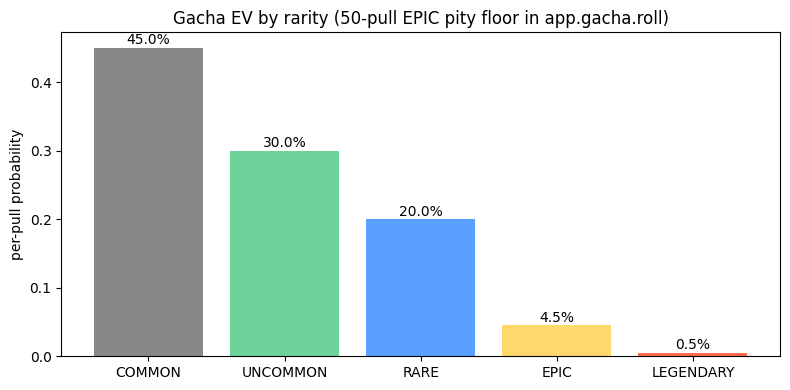

In [5]:
# EV-per-pull chart: bar by rarity using the live RATES table from app.gacha.
rates = dict(RATES)
labels = [str(r) for r in rates]
values = [rates[r] for r in rates]
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, values, color=['#888', '#6dd39a', '#59a0ff', '#ffd86b', '#ff6b4a'])
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f'{v*100:.1f}%', ha='center', fontsize=10)
ax.set_ylabel('per-pull probability')
ax.set_title(f'Gacha EV by rarity (50-pull EPIC pity floor in app.gacha.roll)')
fig.tight_layout()
fig.savefig('output/gacha_ev_by_rarity.png', dpi=120, facecolor='white')
plt.show()